# Task 1: Dataset Selection, Preprocessing & Feature Engineering

## Dataset: iAWE (Indian Ambient Weather and Energy)
**Justification:** The rubric requires *"timestamped voltage and current measurements."* iAWE is the only publicly available residential NILM dataset that natively records **Vrms, Irms, Active Power (P), Reactive Power (Q), Apparent Power (S), Frequency, and Power Factor** at 1 Hz per appliance — exactly matching Nova's hardware setup.

**Sampling Frequency:** Native 1 Hz, resampled to **6 seconds** (0.167 Hz) for the deep learning model.

**Target Appliances (2 classes):**
| Appliance | Meter | Class | ON Power |
|-----------|-------|-------|----------|
| Air Conditioner | Meter 4 | High-power cycling (Type 2) | ~1700 W |
| Motor / Water Pump | Meter 3 | Low-power intermittent (Type 1) | ~80–340 W |

In [38]:
import numpy as np
import pandas as pd
import tables
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path('data')
H5_PATH  = DATA_DIR / 'iawe.h5'

print('Libraries loaded.')

Libraries loaded.


---
## 1. Load & Align Raw Data

Each iAWE meter records at a slightly different rate (~1 Hz for mains, ~1/14 Hz for sub-meters). We:
1. Resample every meter into clean **6-second buckets** using `.resample('6s').mean()`.
2. Create a **common time grid** covering the overlap period of all meters.
3. Reindex each meter to this grid — for sub-meters, small gaps (<=12 s) are linearly interpolated; larger gaps are filled with **0** (appliance OFF).

In [39]:
def load_and_align():
    """Load iAWE meters, align timestamps, and return a clean DataFrame."""
    with tables.open_file(str(H5_PATH), mode='r') as f:
        def load_meter(path, col=0):
            raw  = f.get_node(path)[:]
            idx  = pd.to_datetime(raw['index'], unit='ns')
            vals = raw['values_block_0'][:, col]
            return pd.Series(vals, index=idx, dtype='float32').resample('6s').mean()

        # Aggregate = Phase 1 (Meter 1) + Phase 2 (Meter 2)
        print('Loading Mains Phase 1 & 2...')
        m1 = load_meter('/building1/elec/meter1/table')
        m2 = load_meter('/building1/elec/meter2/table')
        agg = (m1 + m2).dropna()

        # Vrms and Irms from Meter 1 for feature engineering
        vrms_raw = load_meter('/building1/elec/meter1/table', col=4)
        irms_raw = load_meter('/building1/elec/meter1/table', col=6)
        # Reactive power from Meter 1
        q_raw    = load_meter('/building1/elec/meter1/table', col=1)

        # Sub-meters
        print('Loading AC (Meter 4) and Motor (Meter 3)...')
        ac    = load_meter('/building1/elec/meter4/table')
        motor = load_meter('/building1/elec/meter3/table')

    # Common time grid = overlap of all meters
    start = max(agg.index[0], ac.index[0], motor.index[0])
    end   = min(agg.index[-1], ac.index[-1], motor.index[-1])
    grid  = pd.date_range(start, end, freq='6s')
    print(f'Overlap period: {start.date()} to {end.date()} ({len(grid)} time slots)')

    # Reindex to grid
    agg_g   = agg.reindex(grid).interpolate(limit=5).ffill().bfill()
    vrms_g  = vrms_raw.reindex(grid).interpolate(limit=5).ffill().bfill()
    irms_g  = irms_raw.reindex(grid).interpolate(limit=5).ffill().bfill()
    q_g     = q_raw.reindex(grid).interpolate(limit=5).ffill().bfill()
    ac_g    = ac.reindex(grid).interpolate(limit=2).fillna(0).clip(lower=0)
    motor_g = motor.reindex(grid).interpolate(limit=2).fillna(0).clip(lower=0)
    agg_g   = agg_g.clip(lower=0)

    df = pd.DataFrame({
        'Aggregate': agg_g,
        'Vrms': vrms_g,
        'Irms': irms_g,
        'Reactive_Q': q_g.clip(lower=0),
        'AC': ac_g,
        'Motor': motor_g
    }).dropna()

    return df

df = load_and_align()
print(f'\n=== Aligned Dataset ===')
print(f'Rows: {len(df):,}  |  Columns: {list(df.columns)}')
print(f'AC ON (>50 W): {(df.AC>50).mean()*100:.1f}%  |  Motor ON (>10 W): {(df.Motor>10).mean()*100:.1f}%')
print(f'Sanity check (Agg >= AC+Motor): {(df.Aggregate >= df.AC+df.Motor-10).mean()*100:.1f}%')
df.head()

Loading Mains Phase 1 & 2...
Loading AC (Meter 4) and Motor (Meter 3)...
Overlap period: 2013-06-07 to 2013-08-05 (849885 time slots)

=== Aligned Dataset ===
Rows: 849,885  |  Columns: ['Aggregate', 'Vrms', 'Irms', 'Reactive_Q', 'AC', 'Motor']
AC ON (>50 W): 7.9%  |  Motor ON (>10 W): 61.6%
Sanity check (Agg >= AC+Motor): 99.9%


,Aggregate,Vrms,Irms,Reactive_Q,AC,Motor
2013-06-07 15:04:48,897.306152,219.177994,2.041583,148.215332,1716.187378,112.187340
2013-06-07 15:04:54,965.816589,219.046997,2.044996,147.980194,712.968750,112.092674
2013-06-07 15:05:00,1035.964600,218.955002,2.034020,147.780197,374.571167,111.952827
2013-06-07 15:05:06,2314.793701,217.408600,2.031994,144.772400,373.238861,111.841003
2013-06-07 15:05:12,2613.109619,217.144241,2.030165,144.235504,371.461334,111.522499


---
## 2. Exploratory Data Analysis (EDA)

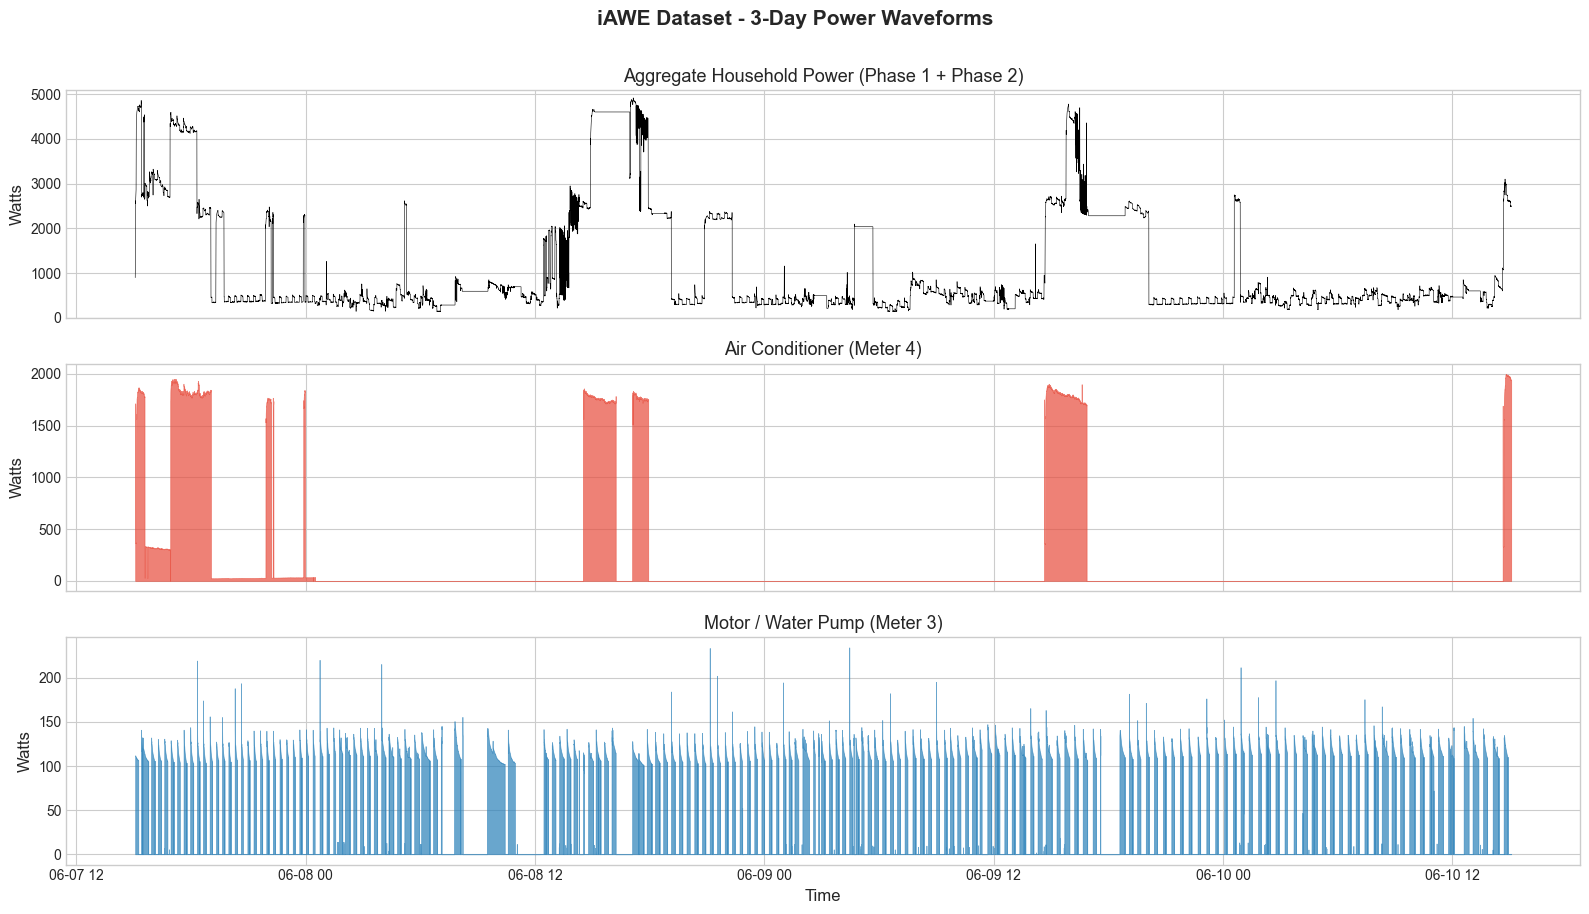

In [40]:
# --- EDA Plot 1: 3-Day Time-Series Waveforms ---
plot_df = df.iloc[:43200]  # 3 days at 6s = 43,200 rows

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

axes[0].plot(plot_df.index, plot_df['Aggregate'], color='black', linewidth=0.4)
axes[0].set_title('Aggregate Household Power (Phase 1 + Phase 2)', fontsize=13)
axes[0].set_ylabel('Watts')
axes[0].set_ylim(0, plot_df['Aggregate'].quantile(0.99)*1.1)

axes[1].fill_between(plot_df.index, plot_df['AC'], color='#e74c3c', alpha=0.7)
axes[1].set_title('Air Conditioner (Meter 4)', fontsize=13)
axes[1].set_ylabel('Watts')

axes[2].fill_between(plot_df.index, plot_df['Motor'], color='#2980b9', alpha=0.7)
axes[2].set_title('Motor / Water Pump (Meter 3)', fontsize=13)
axes[2].set_ylabel('Watts')
axes[2].set_xlabel('Time')

plt.suptitle('iAWE Dataset - 3-Day Power Waveforms', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

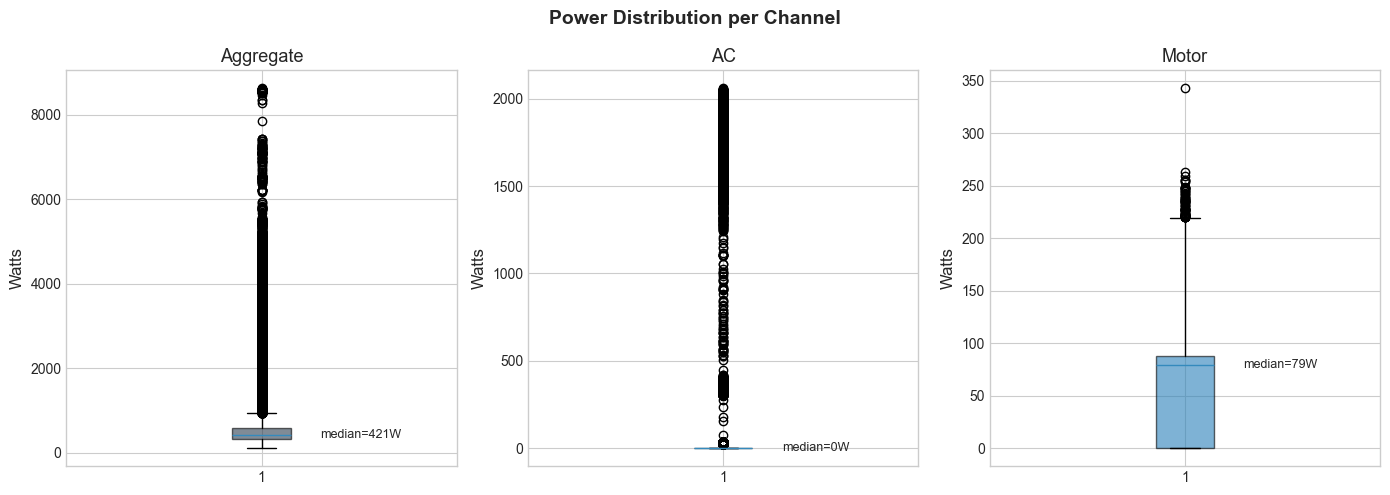

In [41]:
# --- EDA Plot 2: Power Distribution Boxplots ---
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

cols_and_colors = [('Aggregate', '#2c3e50'), ('AC', '#e74c3c'), ('Motor', '#2980b9')]

for i, (col, color) in enumerate(cols_and_colors):
    data = df[col]
    bp = axes[i].boxplot(data.values, patch_artist=True, vert=True)
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.6)
    axes[i].set_title(f'{col}', fontsize=13)
    axes[i].set_ylabel('Watts')
    median = data.median()
    axes[i].text(1.15, median, f'median={median:.0f}W', va='center', fontsize=9)

plt.suptitle('Power Distribution per Channel', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

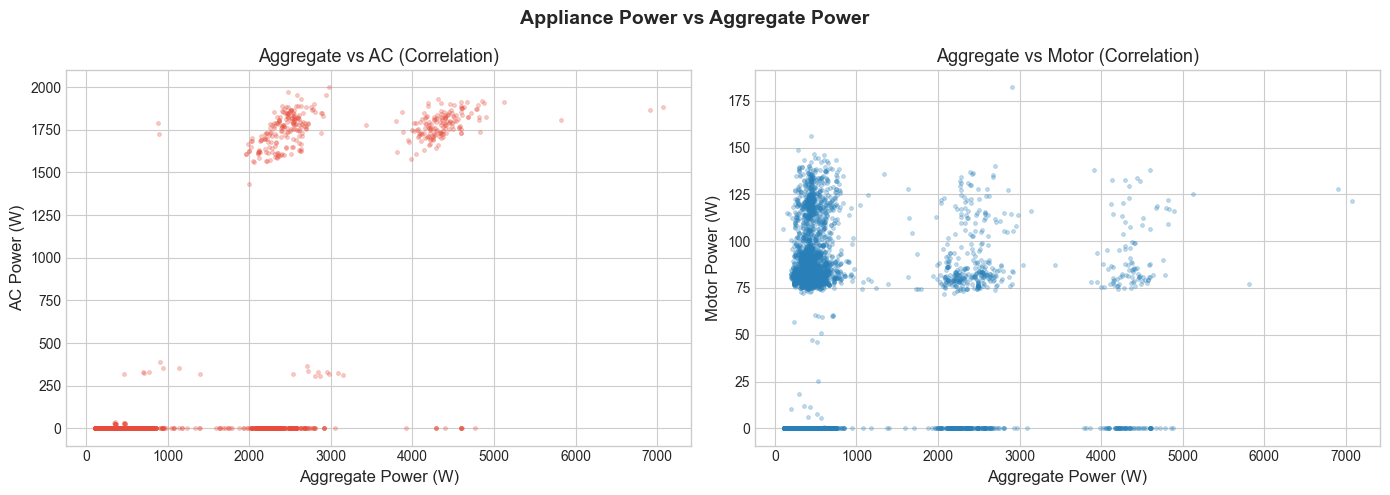

In [42]:
# --- EDA Plot 3: Scatter — Aggregate vs Each Appliance ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subsample for speed
sample = df.sample(n=min(5000, len(df)), random_state=42)

axes[0].scatter(sample['Aggregate'], sample['AC'], alpha=0.3, s=8, c='#e74c3c')
axes[0].set_xlabel('Aggregate Power (W)')
axes[0].set_ylabel('AC Power (W)')
axes[0].set_title('Aggregate vs AC (Correlation)', fontsize=13)

axes[1].scatter(sample['Aggregate'], sample['Motor'], alpha=0.3, s=8, c='#2980b9')
axes[1].set_xlabel('Aggregate Power (W)')
axes[1].set_ylabel('Motor Power (W)')
axes[1].set_title('Aggregate vs Motor (Correlation)', fontsize=13)

plt.suptitle('Appliance Power vs Aggregate Power', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

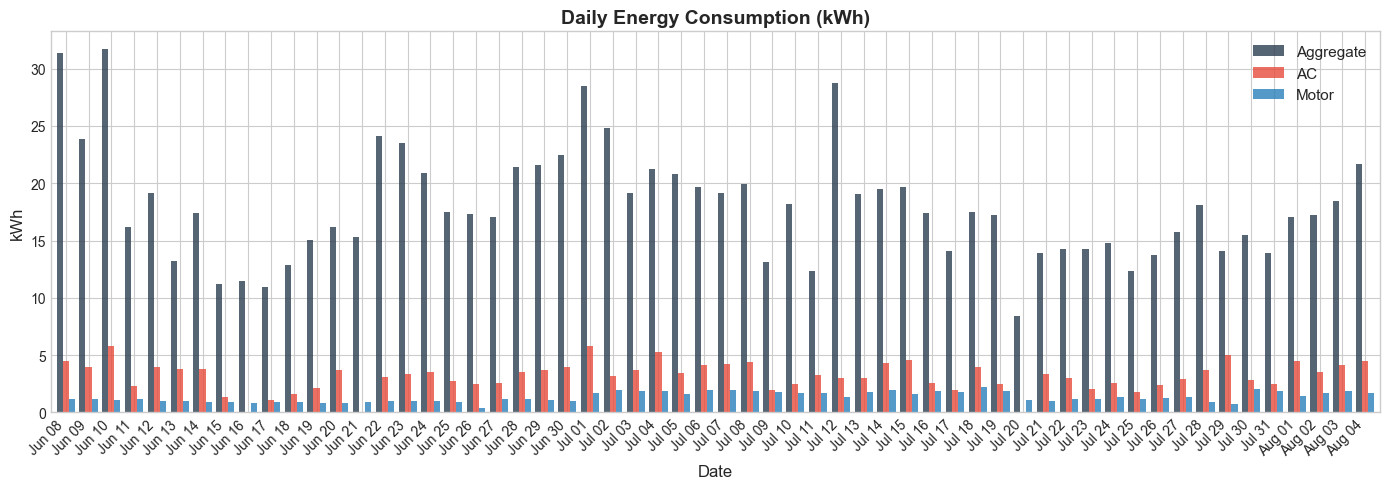

In [43]:
# --- EDA Plot 4: Daily Energy Consumption ---
daily_kwh = df[['Aggregate','AC','Motor']].resample('D').mean() * 24 / 1000
daily_kwh = daily_kwh.iloc[1:-1]

fig, ax = plt.subplots(figsize=(14, 5))
daily_kwh.plot(kind='bar', ax=ax, color=['#2c3e50','#e74c3c','#2980b9'], alpha=0.8, width=0.8)
ax.set_title('Daily Energy Consumption (kWh)', fontsize=14, fontweight='bold')
ax.set_ylabel('kWh')
ax.set_xlabel('Date')
ax.set_xticklabels([d.strftime('%b %d') for d in daily_kwh.index], rotation=45, ha='right')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
## 3. Feature Engineering
We compute features that the rubric requests: **Vrms, Irms, Apparent Power, Reactive Power, Power Factor, Delta-P, rolling statistics, and temporal features.**

In [44]:
# Electrical features
df['Apparent_Power']  = df['Vrms'] * df['Irms']
df['Power_Factor']    = (df['Aggregate'] / (df['Apparent_Power'] + 1e-6)).clip(0, 1)

# Edge detection
df['Delta_P']         = df['Aggregate'].diff().fillna(0)

# Rolling statistics
df['Rolling_Mean']    = df['Aggregate'].rolling(10, min_periods=1).mean()
df['Rolling_Std']     = df['Aggregate'].rolling(10, min_periods=1).std().fillna(0)

# Temporal
df['Hour']            = df.index.hour

print('Feature Engineering Complete.')
print(f'Final columns ({df.shape[1]}): {list(df.columns)}')
df.head()

Feature Engineering Complete.
Final columns (12): ['Aggregate', 'Vrms', 'Irms', 'Reactive_Q', 'AC', 'Motor', 'Apparent_Power', 'Power_Factor', 'Delta_P', 'Rolling_Mean', 'Rolling_Std', 'Hour']


,Aggregate,Vrms,Irms,Reactive_Q,AC,Motor,Apparent_Power,Power_Factor,Delta_P,Rolling_Mean,Rolling_Std,Hour
2013-06-07 15:04:48,897.306152,219.177994,2.041583,148.215332,1716.187378,112.187340,447.470123,1.0,0.000000,897.306152,0.000000,15
2013-06-07 15:04:54,965.816589,219.046997,2.044996,147.980194,712.968750,112.092674,447.950226,1.0,68.510437,931.561371,48.444195,15
2013-06-07 15:05:00,1035.964600,218.955002,2.034020,147.780197,374.571167,111.952827,445.358856,1.0,70.148010,966.362447,69.330835,15
2013-06-07 15:05:06,2314.793701,217.408600,2.031994,144.772400,373.238861,111.841003,441.772980,1.0,1278.829102,1303.470261,676.587926,15
2013-06-07 15:05:12,2613.109619,217.144241,2.030165,144.235504,371.461334,111.522499,440.838623,1.0,298.315918,1565.398132,828.468144,15


---
## 4. Save Preprocessed Data

In [45]:
out_path = DATA_DIR / 'iawe_preprocessed.pkl'
df.to_pickle(out_path)

print(f'Saved {len(df):,} rows x {df.shape[1]} columns to {out_path}')
print(f'Date range: {df.index[0]} -> {df.index[-1]}')
print(f'File size: {out_path.stat().st_size / 1e6:.1f} MB')

Saved 849,885 rows x 12 columns to data\iawe_preprocessed.pkl
Date range: 2013-06-07 15:04:48 -> 2013-08-05 15:33:12
File size: 54.4 MB
